# Emissões de CO₂ nas cadeias produtivas brasileiras

Este notebook estima as emissões da produção brasileira em 2015 e apresenta duas atribuições do mesmo total: **por atividade emissora** e **por atividade da demanda final**. A exposição desenvolve os objetos da contabilidade ambiental, relaciona-os às metodologias de Sanguinet e Azzoni (2024) e Marques et al. (2012) e aplica as contas à matriz de insumo-produto brasileira.


## 1. Objetivo, dados e abrangência

![Figura de motivação](apresentacao_exploratoria/motivação.png)

A produção de um bem mobiliza atividades ao longo de uma cadeia. As emissões podem ser identificadas pelo setor em que ocorrem ou atribuídas à demanda final atendida por essa cadeia. As perguntas desta análise são:

1. **Onde as emissões ocorrem?** Quanto CO₂ é gerado em cada atividade produtiva?
2. **Qual demanda final mobiliza essas emissões?** Quanto CO₂ é gerado na cadeia nacional para atender à demanda final por produtos de cada atividade?

### Fontes e preparação dos dados

A base econômica é a **MIP nacional do IBGE de 2015**, com **67 atividades e 127 produtos**. As intensidades de emissão provêm da Tabela 2 de Sanguinet e Azzoni. A comparação das atribuições utiliza também Marques et al.:

- [Sanguinet e Azzoni (2024), *Carbon emissions drivers in Brazilian regional production chains: Value-added and consumption-based approaches*](references/sanguinet_azzoni_2024/carbon_emissions_drivers_brazilian_regional_production_chains.pdf), seção 2.1, p. 2, equações 1 e 3a–3b; Tabela 2. [DOI](https://doi.org/10.1016/j.rspp.2024.100015).
- [Marques et al. (2012), *Income-based environmental responsibility*](references/marques_et_al_2012/income_based_environmental_responsibility.pdf), seção 6.1, p. 62, equações 1 e 2. [DOI](https://doi.org/10.1016/j.ecolecon.2012.09.010).

O vetor de intensidades para 2015 é estimado por interpolação linear dos coeficientes publicados para 2011 e 2018:

$$\varphi=\varphi_{2015}=\varphi_{2011}+\frac47(\varphi_{2018}-\varphi_{2011}).$$

Esses coeficientes são aplicados aos valores monetários de 2015 sem ajuste adicional de preços. A compatibilidade das bases de preços é, portanto, uma limitação da estimativa. As quantidades de emissões calculadas representam esse cenário metodológico, e não um inventário observado em 2015.

### Fronteira da análise

São contabilizadas as emissões **geradas no Brasil** para atender à demanda final por produtos nacionais, incluindo exportações. As emissões ocorridas no exterior na produção dos bens importados ficam fora dessa fronteira. A atribuição à demanda final corresponde, assim, à parcela doméstica das cadeias atendidas pela produção brasileira; não constitui uma pegada completa do consumo dos residentes.

A aplicação utiliza relações contábeis dos artigos em uma MIP nacional. Seu escopo é a comparação setorial dessas duas atribuições em 2015; as análises multirregionais e temporais dos artigos e a atribuição pela renda não são estimadas aqui.


## 2. Notação e quadro de objetos

**Produção bruta** inclui a produção destinada a usos intermediários e finais. **Demanda final** compreende consumo, investimento, variação de estoques e exportações, excluindo as compras intermediárias. Neste recorte, ambos os conceitos se referem à produção de origem nacional.

### Convenções e unidades

- **Vetores:** letras minúsculas, como $x$, $y$, $c$, $u$ e $\varphi$, sempre em formato coluna. O subscrito identifica um elemento: $x_i$ é a produção da atividade $i$.
- **Matrizes e índices:** letras maiúsculas, como $A$, $D$, $L$, $C$ e $F$. O primeiro índice identifica a linha; o segundo, a coluna. Em $C_{ij}$ e $F_{ij}$, $i$ identifica o emissor e $j$ a atividade da demanda final. O índice $p$ identifica produtos.
- **Diagonalização:** $\hat x=\operatorname{diag}(x)$ coloca os elementos de $x$ na diagonal e zeros nas demais posições. Para as intensidades, $\Phi=\operatorname{diag}(\varphi)=\hat\varphi$.
- **Transposição:** $M^\top$ troca linhas por colunas; $(M^\top)_{ji}=M_{ij}$. Se $x$ tem dimensão $67\times1$, $x^\top$ tem dimensão $1\times67$.
- **Potência e inversa:** $A^2=AA$; $M^{-1}$ é a inversa matricial, quando existe. Para $x_i\ne0$, $\hat x^{-1}=\operatorname{diag}(1/x_i)$.
- **Escrita LaTeX:** `^` introduz um sobrescrito, como em `A^2` ou `F^\top`; `\hat{x}` produz o chapéu que indica diagonalização.
- **Identidade e vetor de uns:** $I$ é a matriz identidade, com uns na diagonal e zeros fora dela; $\mathbf1$ é um vetor-coluna de uns, com dimensão compatível com a operação. Para as atividades desta análise, sua dimensão é $67\times1$.
- **Produtos e somatórios:** a justaposição indica produto matricial. Em $\sum_jF_{ij}$, soma-se cada linha, preservando $i$; em $\sum_iF_{ij}$, soma-se cada coluna, preservando $j$. $F\mathbf1$ e $F^\top\mathbf1$ organizam esses resultados como vetores-coluna. $\mathbf1^\top F$ organiza os totais das colunas como vetor-linha.

Em duas dimensões, essas convenções assumem a forma:

$$x=\begin{bmatrix}x_1\\x_2\end{bmatrix},\quad x^\top=\begin{bmatrix}x_1&x_2\end{bmatrix},\quad
\hat x=\begin{bmatrix}x_1&0\\0&x_2\end{bmatrix},\quad \mathbf1=\begin{bmatrix}1\\1\end{bmatrix}.$$

$$F\mathbf1=\begin{bmatrix}F_{11}+F_{12}\\F_{21}+F_{22}\end{bmatrix},\qquad
F^\top\mathbf1=\begin{bmatrix}F_{11}+F_{21}\\F_{12}+F_{22}\end{bmatrix}.$$

Os valores monetários estão em **milhões de reais** e as emissões em **Gg de CO₂**: 1 Gg = 1.000 toneladas. A massa contabilizada é a do dióxido de carbono, distinta da massa de carbono elementar.

### Entradas: MIP e coeficientes de emissão

| Objeto | Símbolo | Dimensão | Interpretação e unidade | Fonte |
|---|---|---|---|---|
| Produção bruta | $x$ | 67 × 1 | Produção por atividade; milhões de reais | IBGE, `'01'!H134:BV134` |
| Demanda final por produto | $f$ | 127 × 1 | Usos finais de produtos nacionais, incluindo exportações; milhões de reais | IBGE, `'03'!BZ6:BZ132` |
| Participação na produção | $D$ | 67 × 127 | Participação de cada atividade na produção de cada produto; adimensional | IBGE, `'13'!C6:DY72` |
| Inversa de Leontief | $L$ | 67 × 67 | Produção de $i$ por unidade de demanda final de $j$; razão monetária adimensional | IBGE, `'15'!C6:BQ72` |
| Intensidade direta estimada | $\varphi$ | 67 × 1 | Emissão no próprio setor por unidade de sua produção; Gg CO₂/milhão de reais de produção | Sanguinet e Azzoni, Tabela 2; interpolação descrita na seção 1 |

### Saídas e objetos calculados

As definições deste quadro são desenvolvidas nas seções 3 e 4.

| Objeto | Símbolo | Dimensão | Interpretação e unidade | Fórmula e identidades |
|---|---|---|---|---|
| Demanda final por atividade | $y$ | 67 × 1 | Demanda convertida de produtos para atividades; milhões de reais | $y=Df$; $x=Ly$ |
| Intensidades diagonalizadas | $\Phi$ | 67 × 67 | Intensidades na diagonal; Gg CO₂/milhão de reais de produção | $\Phi=\operatorname{diag}(\varphi)$ |
| Coeficientes de emissões | $C$ | 67 × 67 | Emissão em $i$ por unidade de demanda final de $j$; Gg CO₂/milhão de reais de demanda final | $C=\Phi L$; $C_{ij}=\varphi_iL_{ij}$ |
| Emissões por origem e destino final | $F$ | 67 × 67 | Quantidade emitida em $i$ atribuída à demanda final de $j$; Gg CO₂ | $F=C\hat y$; $F_{ij}=C_{ij}y_j$ |
| Emissões por setor emissor | $c$ | 67 × 1 | Soma de cada linha de $F$, preservando o emissor $i$; Gg CO₂ | $c=F\mathbf1=Cy=\Phi Ly=\Phi x$; $c_i=\sum_jF_{ij}=\varphi_i x_i$ |
| Emissões por demanda final | $u$ | 67 × 1 | Soma de cada coluna de $F$, preservando o destino $j$; Gg CO₂ | $u=F^\top\mathbf1=\hat yL^\top\varphi$; $u_j=\sum_iF_{ij}=y_j\sum_i\varphi_iL_{ij}$ |


## 3. Demanda final e produção

A matriz $D$ converte a demanda final por produto em demanda final por atividade:

$$y=Df.$$

Na matriz de transações intermediárias, $Z_{ij}$ registra a venda do setor $i$ ao setor $j$. Dividir cada coluna pela produção do comprador fornece os coeficientes técnicos:

$$A=Z\hat x^{-1},\qquad A_{ij}=\frac{Z_{ij}}{x_j}.$$

O balanço entre produção, usos intermediários e demanda final é:

$$x=Ax+y\quad\Longrightarrow\quad x=(I-A)^{-1}y=Ly.$$

A inversa de Leontief $L$ reúne os requisitos produtivos diretos e indiretos. Quando o raio espectral de $A$ é menor que 1, a série converge e:

$$L=I+A+A^2+\cdots,\qquad x=y+Ay+A^2y+\cdots.$$

O termo $y$ representa a produção para uso final; $Ay$, os insumos dessa produção; $A^2y$, os insumos dos fornecedores, e assim sucessivamente. Sob coeficientes fixos, uma mudança $\Delta y$ requer $\Delta x=L\Delta y$.

A implementação utiliza $L$ fornecida pela Tabela 15 do IBGE e confere a identidade $Ly=x$ com a produção informada na MIP.


## 4. Contabilidade das emissões

### 4.1. Intensidades e quantidades

A intensidade direta $\varphi_i$ relaciona emissões à produção do setor emissor. Sua organização diagonal permite calcular os coeficientes de emissões por demanda final:

$$\Phi=\operatorname{diag}(\varphi),\qquad C=\Phi L,\qquad C_{ij}=\varphi_iL_{ij}.$$

$C_{ij}$ mede a emissão no setor $i$ por **1 milhão de reais de demanda final de $j$**, considerando os encadeamentos produtivos. A quantidade correspondente à demanda efetiva $y_j$ é:

$$\boxed{F=C\hat y,\qquad F_{ij}=C_{ij}y_j.}$$

Assim, cada coluna de $C$ recebe o valor monetário da demanda final daquele destino. A unidade resultante é:

$$\frac{\mathrm{Gg\ CO_2}}{\mathrm{R\$\ milhão\ de\ demanda\ final}}
\times\mathrm{R\$\ milhões\ de\ demanda\ final}=\mathrm{Gg\ CO_2}.$$

$F$ registra uma **atribuição contábil** das emissões entre origens e destinos finais. Seus elementos não são transações diretas entre setores nem transferências físicas de CO₂. A diagonal $F_{ii}$ atribui à demanda final de $i$ as emissões ocorridas no próprio setor, incluindo retornos da cadeia representados em $L_{ii}$.

### 4.2. Somas de coeficientes: colunas e linhas de $C$

**Soma de cada coluna.** Mantendo a demanda final $j$, a soma sobre os emissores fornece sua intensidade total de emissões:

$$\sum_iC_{ij}=\sum_i\varphi_iL_{ij}.$$

Todos os termos têm a mesma base: 1 milhão de reais de demanda final de $j$. O resultado, em Gg CO₂/milhão de reais, reúne as emissões do próprio setor e de seus fornecedores diretos e indiretos. A produção desses fornecedores é determinada por $L$.

**Soma de cada linha.** Mantendo o emissor $i$, a soma sobre os destinos é:

$$\sum_jC_{ij}=\varphi_i\sum_jL_{ij}.$$

Cada termo se refere à demanda final de uma atividade diferente. A soma expressa a resposta do emissor a uma variação monetária igual em todos os destinos. Se $q$ é o valor aplicado à demanda final de cada atividade, então:

$$\Delta y=q\mathbf1,\qquad \Delta c_i=q\sum_jC_{ij}.$$

Para $q=\text{1 milhão de reais}$, $\Delta c_i$ em Gg CO₂ tem o mesmo valor numérico que a soma da linha de $C$. A expansão total da demanda é **67 milhões de reais** e a produção varia segundo $L\Delta y$. Esse cenário fixa a demanda final de cada atividade, e não sua produção bruta.

Uma intensidade por unidade de **demanda final agregada** exige definir a composição dessa demanda. Para participações $s_j$ cuja soma é 1, a intensidade no emissor $i$ é $\sum_jC_{ij}s_j$. Com repartição igual entre as 67 atividades, ela é a média da linha, $\frac1{67}\sum_jC_{ij}$. Portanto, a soma da linha é válida para o cenário de demandas iguais; interpretá-la como intensidade por milhão agregado, sem especificar a composição, confunde duas bases monetárias distintas.

### 4.3. Somas de quantidades: linhas e colunas de $F$

**Soma de cada linha: atribuição por emissor.** Somar os destinos finais preserva o setor onde ocorre a emissão:

$$\boxed{c_i=\sum_jF_{ij}=\sum_jC_{ij}y_j=\varphi_i\sum_jL_{ij}y_j=\varphi_i x_i.}$$

$$c=F\mathbf1=Cy=\Phi Ly=\Phi x.$$

$c_i$ é a quantidade emitida no próprio setor para realizar toda a sua produção. A expressão $\Phi x$ parte da produção informada na MIP; $\Phi Ly$ parte dos requisitos da demanda final. A identidade $x=Ly$ torna as duas contas equivalentes.

**Soma de cada coluna: atribuição por demanda final.** Somar os emissores preserva o destino final:

$$\boxed{u_j=\sum_iF_{ij}=y_j\sum_iC_{ij},\qquad u=F^\top\mathbf1=\hat yL^\top\varphi.}$$

$u_j$ reúne as emissões de toda a cadeia nacional atribuídas à demanda final de $j$. Como $y_j$ é comum aos elementos da coluna, ele pode ser colocado fora do somatório. A ponderação ocorre na passagem de $C$ a $F$; a soma de $F$ já resulta em Gg CO₂. Uma nova multiplicação por $y_j$ produziria a unidade Gg CO₂ × milhões de reais, incompatível com uma quantidade de emissões.

| Operação | Índice preservado | Resultado e base de interpretação |
|---|---|---|
| Coluna de $C$: $\sum_iC_{ij}$ | Destino $j$ | Intensidade da cadeia por milhão de reais de demanda final de $j$ |
| Linha de $C$: $\sum_jC_{ij}$ | Emissor $i$ | Coeficiente de resposta em $i$ por milhão de reais aplicado à demanda final **de cada atividade** |
| Linha de $F$: $\sum_jF_{ij}$ | Emissor $i$ | Quantidade emitida em $i$ para todos os destinos; $c_i$, em Gg CO₂ |
| Coluna de $F$: $\sum_iF_{ij}$ | Destino $j$ | Quantidade emitida na cadeia para atender a $y_j$; $u_j$, em Gg CO₂ |

### 4.4. Encadeamentos, emissões diretas e conservação

Expandir a produção requerida explicita as etapas que geram as emissões:

$$c=\Phi Ly=\Phi y+\Phi Ay+\Phi A^2y+\cdots.$$

A emissão é **direta em relação ao setor que a gera** e pode ser **indireta em relação à demanda final atendida**. A emissão do cimento utilizado na construção, por exemplo, ocorre diretamente no cimento e integra indiretamente a cadeia da demanda final de construção. No vetor $c$, ela permanece na posição do cimento; no vetor $u$, a parcela associada à construção é atribuída a esse destino.

As duas atribuições repartem o mesmo total estimado:

$$\mathbf1^\top c=\sum_i\sum_jF_{ij}=\mathbf1^\top u.$$

Somar os totais de $c$ e $u$ contaria as mesmas emissões duas vezes. Setorialmente, $c_i$ e $u_i$ podem diferir porque o primeiro se refere à produção bruta $x_i$, enquanto o segundo se refere à demanda final $y_i$. Por essa razão, $u_i-c_i$ não mede as emissões dos fornecedores de toda a produção de $i$.


## 5. Correspondência com os artigos

### 5.1. Sanguinet e Azzoni: equação 3a

A equação 3a, na seção 2.1 do artigo, relaciona intensidades, requisitos produtivos e demanda final:

$$C_t=\hat\varphi(I-A)^{-1}Y=\hat\varphi L\vartheta\,y_{\mathrm{total}}.$$

O vetor $\vartheta$ contém as participações na demanda final, com $Y=\vartheta y_{\mathrm{total}}$. O símbolo $y_{\mathrm{total}}$ representa aqui o escalar denominado $y$ no artigo. A correspondência é:

| Sanguinet e Azzoni | Neste notebook | Significado |
|---|---|---|
| $Y$ | $y$ | Vetor de demanda final por atividade |
| $\hat\varphi$ | $\Phi$ | Intensidades diagonalizadas |
| $C_t$ | $c$ | Vetor de quantidades emitidas por setor |

Com intensidade diagonal e demanda vetorial, a expressão corresponde a $c=\Phi Ly$. A referência do artigo a emissões diretas e indiretas diz respeito aos requisitos da cadeia explicitados na seção 4.4. A posição no vetor resultante identifica o emissor.

Os símbolos têm funções distintas entre os textos: o $C_t$ do artigo é um vetor de quantidades; o $C$ deste notebook é uma matriz de coeficientes. Da mesma forma, o $F_t$ da abordagem de oferta do artigo não corresponde à matriz $F$ de origem e destino final definida aqui.

### 5.2. Marques et al.: equação 1

Marques parte do vetor $e$ de emissões diretas. Usando $\top$ para a transposta, indicada por uma aspa no artigo:

$$u^\top=(e^\top\hat x^{-1})(I-Z\hat x^{-1})^{-1}\hat y.$$

As duas ocorrências de $\hat x^{-1}$ normalizam objetos diferentes:

- $e^\top\hat x^{-1}=\varphi^\top$ converte quantidades de emissões em intensidades por produção.
- $Z\hat x^{-1}=A$ converte transações intermediárias em coeficientes técnicos por produção do comprador.

Na aplicação nacional, $e=c$ e as entradas já fornecem $\varphi$ e $L$. Substituindo essas definições e usando $\varphi^\top=\mathbf1^\top\Phi$:

$$u^\top=\varphi^\top L\hat y=\mathbf1^\top\Phi L\hat y=\mathbf1^\top F.$$

Portanto, a equação 1 fornece a soma de cada coluna de $F$, conforme a seção 4.3. Seu resultado é a quantidade atribuída à demanda final; $e_i=c_i$ corresponde ao total da linha do emissor, para dados e fronteiras consistentes.

### 5.3. Atribuição pela renda e inversa de Ghosh

A abordagem pela renda acompanha relações a jusante e atribui emissões aos fornecedores de insumos primários remunerados pela atividade produtiva. Na notação da equação 2 de Marques, $v$ é o vetor **monetário de valor adicionado**. Definindo os coeficientes de alocação e a inversa de Ghosh:

$$B=\hat x^{-1}Z,\qquad G=(I-B)^{-1},$$

a expressão é:

$$d=\hat vG\hat x^{-1}e=\hat vG\varphi.$$

Essa terceira atribuição requer objetos diferentes dos usados na conta por produção $c=\Phi x$. A abordagem de oferta/renda também é tratada na equação 3b de Sanguinet e Azzoni, com notação própria. Este notebook calcula $c$ e $u$; a estimação de $d$ e de $G$ permanece fora do escopo definido na seção 1.


## 6. Exemplo numérico integrado

Considere uma economia hipotética com **cimento** e **construção**, nessa ordem. O cimento não utiliza insumos intermediários; a construção utiliza 0,5 real de cimento por 1 real de produção. Não há outros insumos intermediários. Os valores são didáticos, sem correspondência com estimativas da MIP brasileira.

### Produção e demanda final

$$A=\begin{bmatrix}0&0{,}5\\0&0\end{bmatrix},\qquad
L=(I-A)^{-1}=\begin{bmatrix}1&0{,}5\\0&1\end{bmatrix}.$$

Para a demanda final $y=(100,200)^\top$, em milhões de reais:

$$x=Ly=\begin{bmatrix}200\\200\end{bmatrix}.$$

O cimento produz 100 para sua demanda final e 100 como insumo da construção. As intensidades de emissão são 0,10 e 0,02 Gg CO₂/milhão de reais de produção:

$$\Phi=\begin{bmatrix}0{,}10&0\\0&0{,}02\end{bmatrix},\qquad
C=\Phi L=\begin{bmatrix}0{,}10&0{,}05\\0&0{,}02\end{bmatrix}.$$

### As duas somas de $C$

As somas das colunas são **0,10** para cimento e **0,07** para construção, em Gg CO₂/milhão de reais de demanda final de cada atividade. Na coluna de construção, 0,05 é emitido no cimento e 0,02 na construção, por unidade de demanda final de construção.

As somas das linhas são **0,15** para o emissor cimento e **0,02** para o emissor construção. Aplicando 1 milhão de reais à demanda final de cada atividade:

$$\Delta y=\begin{bmatrix}1\\1\end{bmatrix},\quad
\Delta x=L\Delta y=\begin{bmatrix}1{,}5\\1\end{bmatrix},\quad
\Delta c=C\Delta y=\begin{bmatrix}0{,}15\\0{,}02\end{bmatrix}\ \text{Gg CO₂}.$$

A expansão da demanda total é 2 milhões de reais. Para 1 milhão de reais **agregado**, dividido igualmente entre as duas atividades, as emissões seriam metade desses valores: 0,075 Gg no cimento e 0,01 Gg na construção.

### Quantidades em $F$ e suas duas atribuições

Ponderando os coeficientes pela demanda efetiva do exemplo:

$$F=C\hat y=
\begin{bmatrix}0{,}10&0{,}05\\0&0{,}02\end{bmatrix}
\begin{bmatrix}100&0\\0&200\end{bmatrix}
=\begin{bmatrix}10&10\\0&4\end{bmatrix}\quad\text{Gg CO₂}.$$

| Emissor / destino final | Cimento | Construção | Soma da linha: $c$ |
|---|---:|---:|---:|
| Cimento | 10 | 10 | 20 |
| Construção | 0 | 4 | 4 |
| **Soma da coluna: $u$** | **10** | **14** | **24** |

As 10 Gg emitidas no cimento para atender à construção são diretas para o cimento e indiretas para a demanda final da construção. O cimento emite 20 Gg no total, e sua demanda final mobiliza 10 Gg. A construção emite 4 Gg, e sua demanda final mobiliza 14 Gg. As duas atribuições somam 24 Gg.

### Correspondência com as equações dos artigos

A equação 3a de Sanguinet, traduzida para a notação da seção 5, fornece:

$$c=\Phi Ly=\Phi x=\begin{bmatrix}20\\4\end{bmatrix}.$$

Na equação 1 de Marques, $e=c$ e:

$$e^\top\hat x^{-1}=\begin{bmatrix}20/200&4/200\end{bmatrix}
=\begin{bmatrix}0{,}10&0{,}02\end{bmatrix},$$

$$u^\top=\begin{bmatrix}0{,}10&0{,}02\end{bmatrix}
\begin{bmatrix}1&0{,}5\\0&1\end{bmatrix}
\begin{bmatrix}100&0\\0&200\end{bmatrix}
=\begin{bmatrix}10&14\end{bmatrix}.$$


## 7. Implementação e leitura dos resultados

As células seguintes aplicam a contabilidade da seção 4 às **67 atividades** da MIP brasileira. A execução deve seguir a ordem apresentada, com a raiz do repositório como diretório de trabalho. As entradas são verificadas por SHA-256.

Na implementação, `phi` representa $\varphi$; `Phi`, `C`, `F` e `c` correspondem aos objetos homônimos; `emissoes_demanda_final` representa $u$. O operador `@` realiza o produto matricial, enquanto `phi * x` multiplica os elementos correspondentes dos vetores e equivale a $\Phi x$.

Os totais de cada linha de $F$ são obtidos com `F.sum(axis=1)`; os de cada coluna, com `F.sum(axis=0)`. Essas operações reduzem, respectivamente, o eixo das colunas e o eixo das linhas.


### 7.1. Inicialização


In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
from redes import dados, mip

pd.set_option("display.max_rows", 10)
pd.set_option("display.float_format", "{:,.6f}".format)


### 7.2. Leitura e alinhamento das entradas

São carregadas as tabelas da MIP, calculada a demanda por atividade $y=Df$ e preparada a intensidade de 2015 conforme a seção 1. O alinhamento pelos códigos das atividades assegura que as operações combinem setores correspondentes. A identidade $Ly=x$ verifica a compatibilidade entre produção e demanda.


In [2]:
## Carrega MIP

tabelas = dados.carregar_matriz_67("mip_ibge_2015_67")

L = mip.carregar_inversa_leontief_ibge_67(tabelas)
D = mip.carregar_matriz_participacao_tabela_13_67(tabelas)

atividades = pd.Index(tabelas["01"].iloc[3, 7:74].astype(str).str.split().str[0], name="atividade")
x = pd.Series(tabelas["01"].iloc[133, 7:74].to_numpy(dtype=float), index=atividades)

produtos = pd.Index(tabelas["03"].iloc[5:132, 0].astype(str), name="produto")
f = pd.Series(tabelas["03"].iloc[5:132, 77].to_numpy(dtype=float), index=produtos)

assert x.index.equals(L.index) and x.index.equals(L.columns)
assert D.index.equals(x.index) and D.columns.equals(f.index)
y = D @ f

np.testing.assert_allclose(L @ y, x, rtol=0, atol=1e-6)  # Tolerância: R$ 1.

## Carrega e interpola os coeficientes.
coef_2011 = dados.carregar_coeficientes_co2("sanguinet_azzoni_2011")[2011]
coef_2018 = dados.carregar_coeficientes_co2("sanguinet_azzoni_2018")[2018]
assert coef_2011.index.equals(coef_2018.index)

phi = coef_2011 + (4 / 7) * (coef_2018 - coef_2011)
phi = pd.Series(phi.to_numpy(), index=x.index, name="phi")
assert np.isfinite(phi).all() and (phi >= 0).all()

SHA-256 verificado: Matriz_de_Insumo_Produto_2015_Nivel_67.xls.original
SHA-256 verificado: coeficientes_co2_sanguinet_azzoni_2011.csv
SHA-256 verificado: coeficientes_co2_sanguinet_azzoni_2018.csv


### 7.3. Construção dos objetos de emissões


**Intensidades diagonalizadas.** A matriz $\Phi=\operatorname{diag}(\varphi)$ organiza as intensidades na diagonal e zeros nas demais posições, conforme a seção 4.1.


In [3]:
Phi = pd.DataFrame(
    np.diag(phi),
    index=phi.index,
    columns=phi.index,
)

**Requisitos produtivos.** A matriz $L$, carregada da Tabela 15 do IBGE, contém os requisitos diretos e indiretos de produção descritos na seção 3.


**Coeficientes de emissões.** O produto $C=\Phi L$ pondera cada linha de $L$ pela intensidade do emissor, obtendo coeficientes em Gg CO₂/milhão de reais de demanda final.


In [4]:
C = Phi @ L

**Atribuição por emissor.** O produto elemento a elemento `phi * x` calcula $c_i=\varphi_i x_i$, em Gg CO₂, como definido na seção 4.3.


In [5]:
c = phi * x
c.name = "emissoes_diretas_gg_co2"


**Origem e destino final.** `C.mul(y, axis=1)` multiplica cada coluna $j$ de $C$ por $y_j$, alinhando os códigos das atividades. O resultado é $F=C\hat y$, em Gg CO₂.


In [6]:
F = C.mul(y, axis=1)

### 7.4. Verificação e comparação das atribuições

A soma de cada coluna de $F$ calcula $u$ e é armazenada em `emissoes_demanda_final`. Antes da comparação gráfica, são verificadas as identidades $F\mathbf1=c$ e $\mathbf1^\top c=\mathbf1^\top u$. Como $F\mathbf1=Cy$, a primeira verificação também compara as emissões obtidas a partir da produção e da demanda.

O gráfico apresenta, para cada atividade:

- **Emissões diretas:** $c_i$, emitidas no próprio setor para realizar a produção bruta $x_i$.
- **Emissões incorporadas na demanda final:** $u_i$, emitidas na cadeia nacional para atender à demanda final $y_i$.

Uma barra de demanda final menor que a de emissões diretas é compatível com essas bases de atribuição distintas; a diferença não indica emissões indiretas negativas. A interpretação segue a seção 4.4 e a fronteira nacional definida na seção 1.

As 67 atividades são ordenadas pelas emissões incorporadas na demanda final, em ordem decrescente. A comparação utiliza a matriz $F$ completa, incluindo sua diagonal e todos os valores, sem filtragem por limiar.


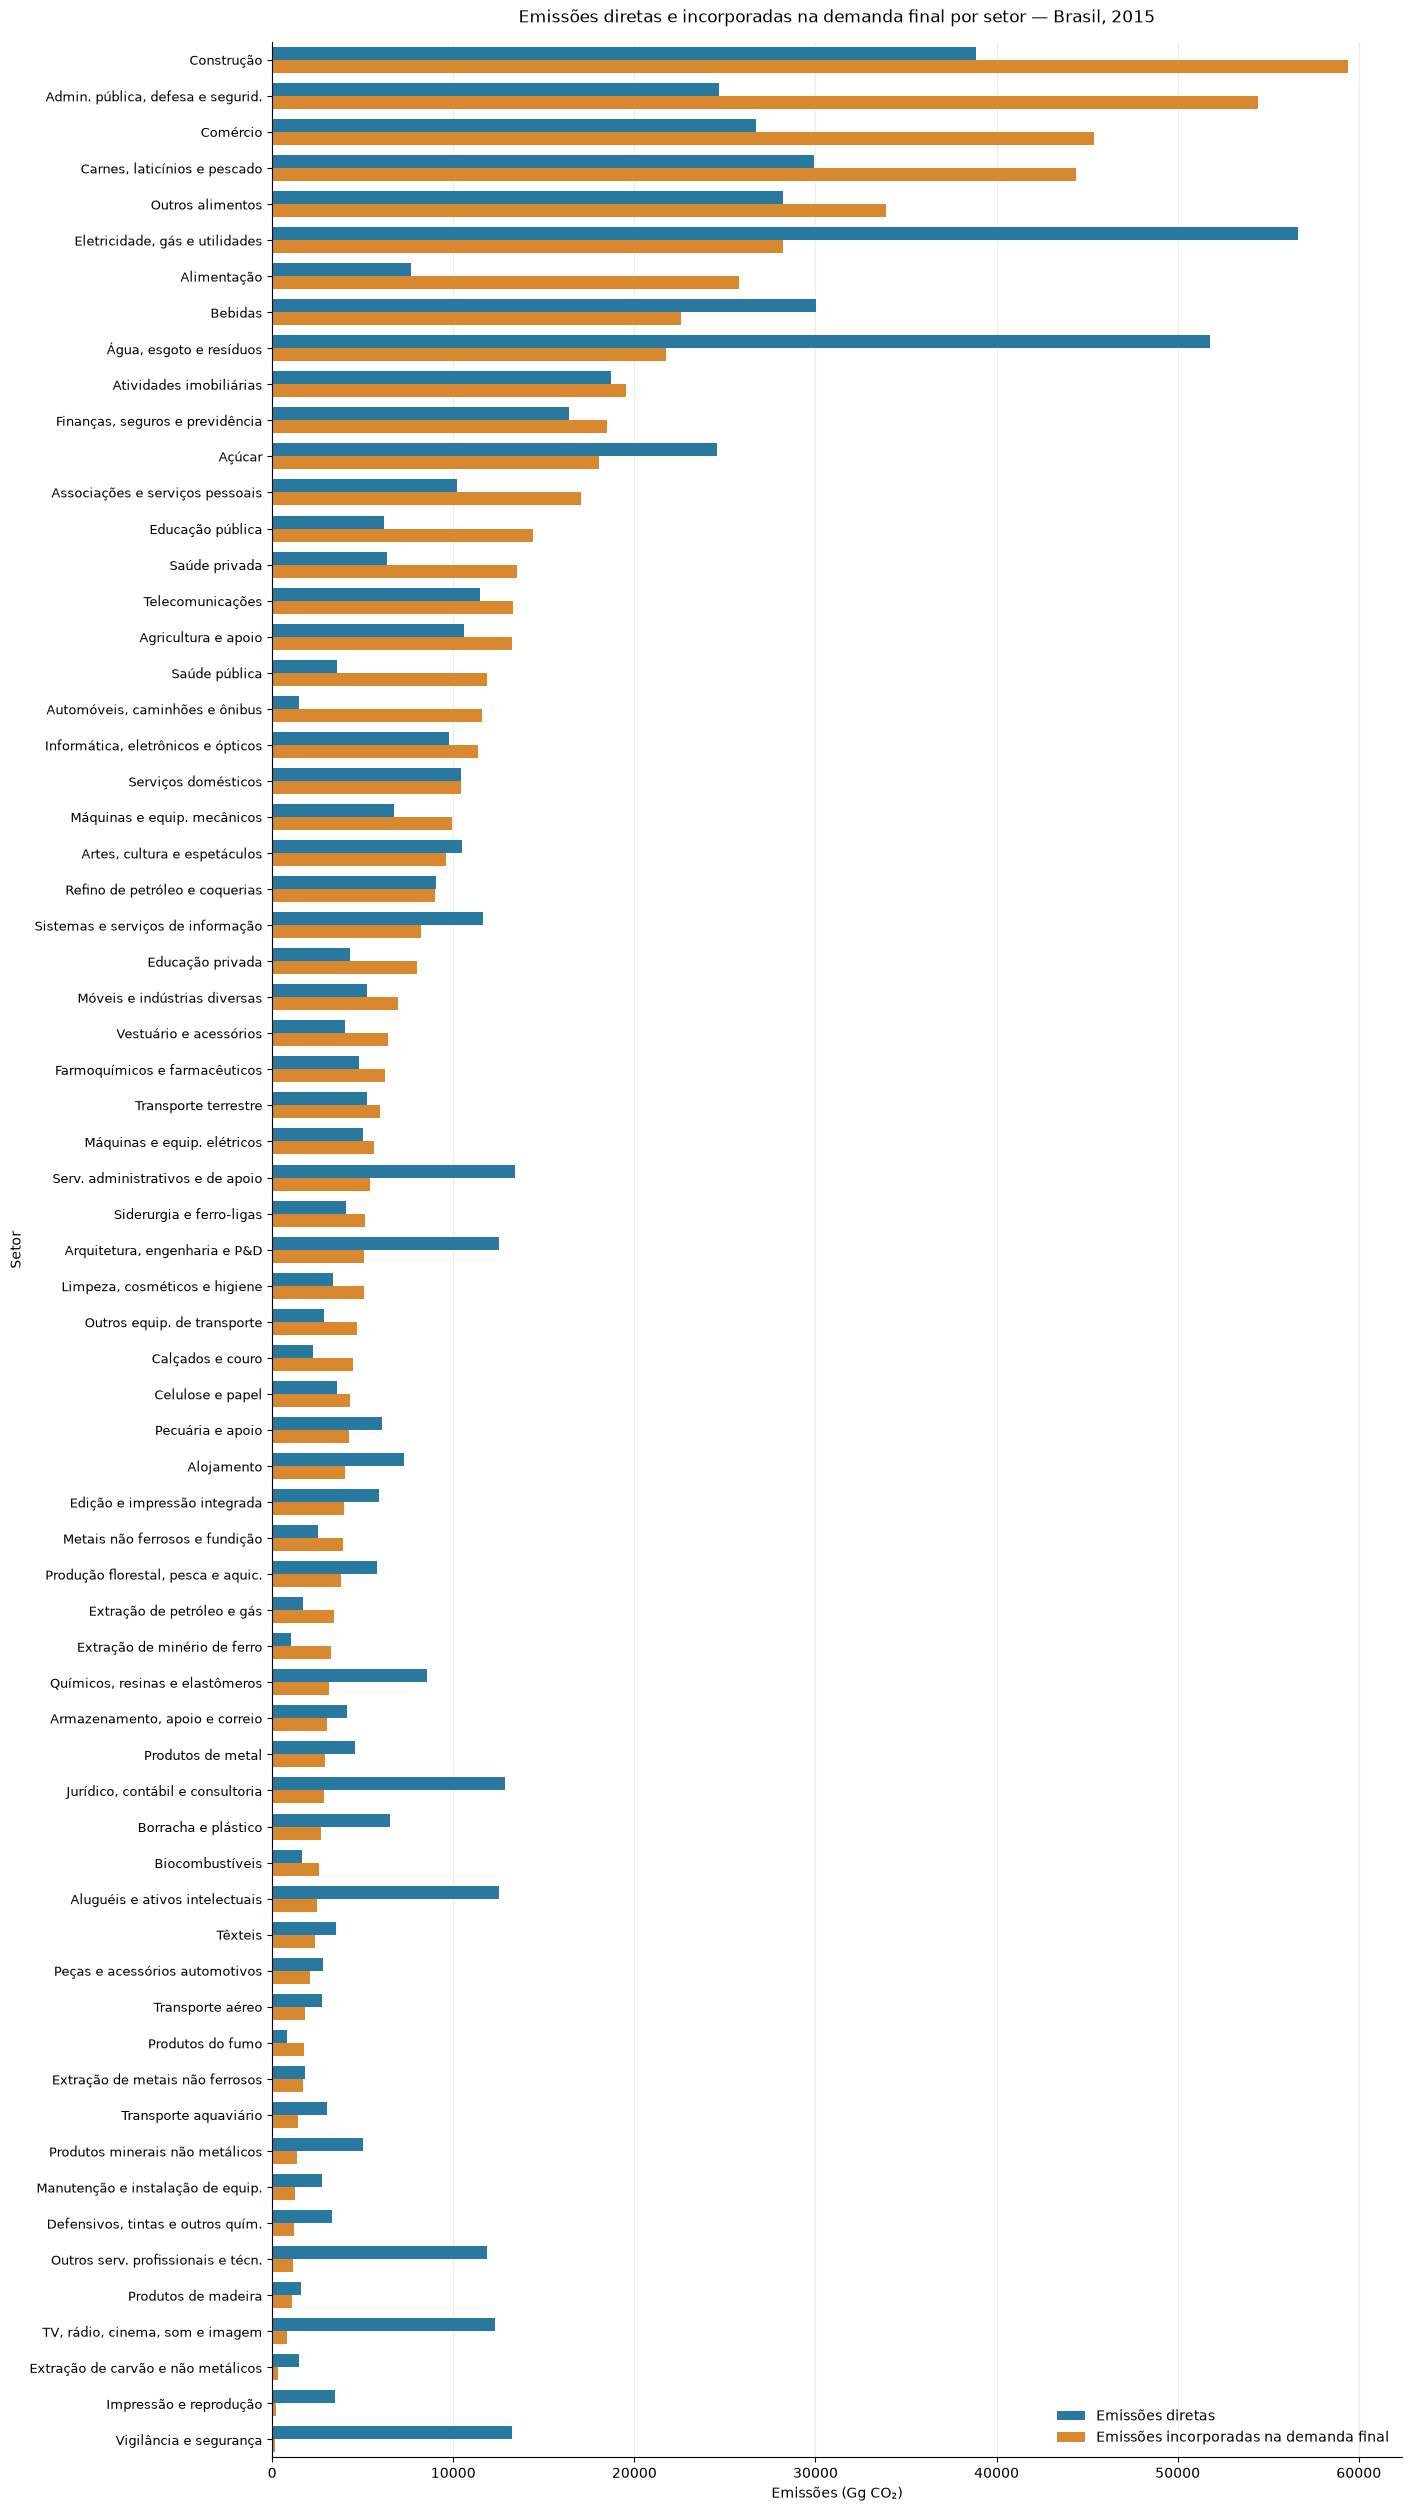

In [7]:
import matplotlib.pyplot as plt
from redes.visualizacoes import ROTULOS_ATIVIDADES_IBGE

emissoes_demanda_final = F.sum(axis=0)

# Com x = Ly, a soma de cada linha de F recupera as emissões diretas.
np.testing.assert_allclose(F.sum(axis=1), c, rtol=1e-8, atol=1e-6)
np.testing.assert_allclose(emissoes_demanda_final.sum(), c.sum(), rtol=1e-8, atol=1e-6)

comparacao_emissoes = pd.DataFrame({
    "Emissões diretas": c,
    "Emissões incorporadas na demanda final": emissoes_demanda_final,
}).sort_values("Emissões incorporadas na demanda final", ascending=False)

rotulos_setores = [ROTULOS_ATIVIDADES_IBGE[str(codigo)] for codigo in comparacao_emissoes.index]
posicoes = np.arange(len(comparacao_emissoes))
altura_barra = 0.36

fig, ax = plt.subplots(figsize=(14, 25), layout="constrained")
ax.barh(
    posicoes - altura_barra / 2,
    comparacao_emissoes["Emissões diretas"],
    height=altura_barra, color="#2878A0", label="Emissões diretas",
)
ax.barh(
    posicoes + altura_barra / 2,
    comparacao_emissoes["Emissões incorporadas na demanda final"],
    height=altura_barra, color="#D88930", label="Emissões incorporadas na demanda final",
)
ax.set_yticks(posicoes, labels=rotulos_setores, fontsize=9)
ax.invert_yaxis()
ax.set_ylim(len(comparacao_emissoes) - 0.5, -0.5)
ax.set_xlabel("Emissões (Gg CO₂)")
ax.set_ylabel("Setor")
ax.set_title("Emissões diretas e incorporadas na demanda final por setor — Brasil, 2015", pad=14)
ax.ticklabel_format(axis="x", style="plain")
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False)
plt.show()
